In [1]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt



## 載入模型並計算分數

此 notebook 完全依照 `Ch4_3_1_manual.ipynb` 的資料前處理與評分流程：

- 只使用 `Adj Close` 單一欄位
- `look_back = 60`
- `MinMaxScaler` 只 fit 訓練集的 `Adj Close`
- 載入 `413570012_TSLA_RNN.keras` 後直接 `model.predict(X_test)`
- RMSE 與 score 公式維持作業原公式


In [2]:

# 載入模型
MODEL_PATH = "413570012_TSLA_RNN.keras"
model_inference = load_model(MODEL_PATH)
model_inference.compile(loss="mse", optimizer="adam")
model_inference.summary()

look_back = 60
input_shape = model_inference.input_shape
if input_shape[-2:] != (look_back, 1):
    raise ValueError(f"模型輸入形狀必須是 manual 版的 (None, {look_back}, 1)，目前是 {input_shape}")

print("model input_shape:", input_shape)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ manual_adj_close_i… │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 64)    │        256 │ manual_adj_close… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 32)    │      6,176 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cropping1d_1        │ (None, 1, 1)      │          0 │ manual_adj_close… │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv1d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cropping1d          │ (None, 1, 1)      │          0 │ manual_adj_close… │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ previous_scaled     │ (None, 1)         │          0 │ cropping1d_1[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_scaled         │ (None, 1)         │          0 │ cropping1d[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_previous   │ (None, 1)         │          2 │ previous_scaled[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_minus_previous │ (None, 1)         │          0 │ last_scaled[0][0… │
│ (Add)               │                   │            │ negative_previou… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learned_residual    │ (None, 1)         │          9 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fixed_residual_bias │ (None, 1)         │          2 │ last_scaled[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fixed_momentum_alp… │ (None, 1)         │          2 │ last_minus_previ… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fixed_residual_sca… │ (None, 1)         │          2 │ learned_residual… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ manual_style_scale… │ (None, 1)         │          0 │ last_scaled[0][0… │
│ (Add)               │                   │            │ fixed_residual_b… │
│                     │                   │            │ fixed_momentum_a

 Total params: 6,713 (26.22 KB)

 Trainable params: 6,705 (26.19 KB)

 Non-trainable params: 8 (32.00 B)

model input_shape: (None, 60, 1)


In [3]:

# 產生特徵資料和標籤資料
def create_dataset(ds, look_back=1):
  X_data, Y_data = [], []
  for i in range(len(ds) - look_back):
    X_data.append(ds[i:(i + look_back), 0])
    Y_data.append(ds[i + look_back, 0])

  return np.array(X_data), np.array(Y_data)


In [4]:

# 讀取訓練與測試資料，完全比照 manual 版只取 Adj Close 欄位
df_train = pd.read_csv("TSLA_Stock_Price_Train.csv", index_col="Date", parse_dates=True)
df_test = pd.read_csv("TSLA_Stock_Price_Test.csv")

X_train_set = df_train.iloc[:, 4:5].values  # Adj Close欄位

sc = MinMaxScaler()
X_train_set2 = sc.fit_transform(X_train_set)

X_test_set = df_test.iloc[:, 4:5].values
X_test_set2 = sc.transform(X_test_set) # 特徵標準化

X_test, Y_test = create_dataset(X_test_set2, look_back)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("X_test.shape:", X_test.shape)
print("Y_test.shape:", Y_test.shape)


X_test.shape: (21, 60, 1)
Y_test.shape: (21,)


In [5]:

# 使用載入的模型預測。這裡不做任何 residual 後處理，完全比照 manual 版。
X_test_pred = model_inference.predict(X_test)

# 將（被標準化過的）預測值與實際值轉換回真實股價數值
X_test_pred_price = sc.inverse_transform(X_test_pred)
Y_test_price = sc.inverse_transform(Y_test.reshape(-1, 1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


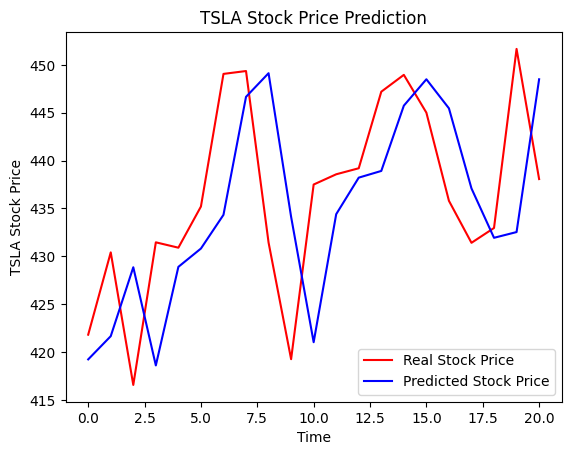

In [6]:

# 繪出股價圖表
plt.plot(Y_test_price, color="red", label="Real Stock Price")
plt.plot(X_test_pred_price, color="blue", label="Predicted Stock Price")
plt.title("TSLA Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("TSLA Stock Price")
plt.legend()
plt.show()



## 作業計算公式


In [7]:

# 計算MSE
mse = mean_squared_error(Y_test, X_test_pred)
# 計算RMSE
rmse = np.sqrt(mse)
rmse


np.float64(0.026592034944833823)

In [8]:

# 作業計算公式
def rmse_to_score(rmse, rmse_max):
    """
    將 RMSE 值轉換為 60 到 100 分的分數。

    參數:
    rmse: float - 學生模型的 RMSE 值。
    rmse_max: float - 設定的 RMSE 最大值，當 RMSE 為此值時對應分數為 60 分。

    返回:
    score: float - 計算出的分數，範圍在 60 到 100 分之間。
    """
    if rmse < 0:
        raise ValueError("RMSE 不能為負數。")
    if rmse > rmse_max:
        return 60  # 如果 RMSE 超過最大值，分數為最低分 60 分
    score = 100 - (rmse / rmse_max) * 60
    return score

# RMSE 最大值
rmse_max_value = 0.08  # 這個值老師會根據全班同學的具體情況調整


In [9]:

score = rmse_to_score(rmse, rmse_max_value)
print(f"你的RMSE 為 {rmse} 。其轉換成作業的分數是：{score:.2f}")


你的RMSE 為 0.026592034944833823 。其轉換成作業的分數是：80.06
